In [1]:
from random import choice
import matplotlib.pyplot as plt

In [9]:
class RandomWalk:
    """Classes that generate random walk data"""
    def __init__(self,num_points=50_000):
        """Initialize random walk class"""
        self.num_points = num_points

        #all the randomwalk start from (0,0)
        self.x_values = [0]
        self.y_values = [0]

    #Refactoring the function of step generation
    def get_step(self):
        """Generate random walk step"""
        direction = choice([-1,1])
        distance = choice([0,1,2,3,4,5,6])
        step = direction * distance
        return step

    def fill_walk(self):
        """Fill random walk data"""
        while len(self.x_values) < self.num_points:
            x_step = self.get_step()
            y_step = self.get_step()

            #refuse to stay in one place
            if x_step == 0 and y_step == 0:
                continue

            #figure out the x_values and y_values of next point
            x = self.x_values[-1] + x_step
            y = self.y_values[-1] + y_step
            self.x_values.append(x)
            self.y_values.append(y)

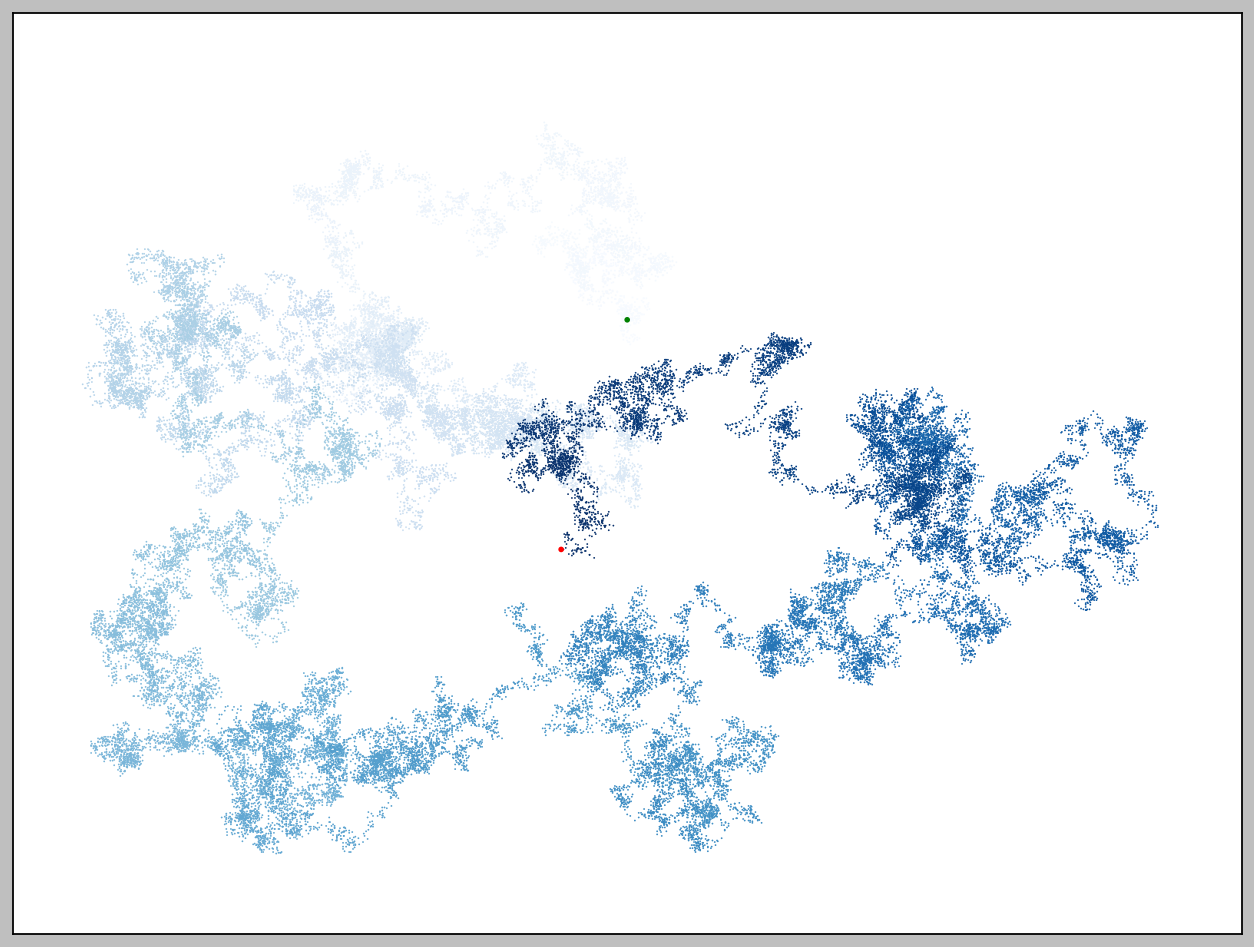

In [10]:
#when the program running,continuously simulate random walk
while True:
    #create a RandomWalk example
    rw = RandomWalk()
    rw.fill_walk()

    #Draw each point
    plt.style.use('classic')
    fig,ax = plt.subplots(figsize=(15,9), dpi=128)
    point_numbers = range(rw.num_points)
    ax.scatter(rw.x_values,rw.y_values,c=point_numbers,cmap=plt.cm.Blues,edgecolors='none',s=1)
    ax.set_aspect('equal')

    #Highlight the start and end points
    ax.scatter(0,0,c='green',edgecolors='none',s=10)
    ax.scatter(rw.x_values[-1],rw.y_values[-1],c='red',edgecolors='none',s=10)

    #Hidden coordinate axes
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.show()

    keeprunning = input("Make another walk? (y/n):")
    if keeprunning == "n":
        break